# Training-Free Proxy vs GBM-Probe JRN: Cross-Dataset Diagnostic Reliability

This notebook demonstrates the analysis of **Join Reproduction Number (JRN)** estimation using training-free proxies across two relational datasets: **rel-stack** and **rel-avito**.

**What this experiment does:**
- Computes GBM-probe JRN (ground truth) and 5 training-free proxies (entropy reduction, mutual information, Pearson correlation, log fan-out, homophily) for 24 (join, task) pairs
- Evaluates proxy reliability via Spearman rank correlation, ROC-AUC for join selection, and cross-dataset consistency
- Key finding: **mutual_information** is the strongest pooled proxy (Spearman ρ=0.747), **log_mean_fanout** achieves best join-selection AUC (0.941)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python>=3.11; use 1.15.3 on Python 3.10
    _v = sys.version_info
    _pip(f'scipy=={"1.16.3" if _v >= (3, 11) else "1.15.3"}')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aii-pipeline 0.1.0 requires pandas>=2.3.0, but you have pandas 2.2.2 which is incompatible.
aii-pipeline 0.1.0 requires scikit-learn>=1.7.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import warnings
from typing import Any, Dict, List

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## Data Loading

Load pre-computed results for 24 (join, task) pairs across rel-stack (15 pairs) and rel-avito (9 pairs). Each result contains GBM-probe JRN and 5 training-free proxy values.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/experiment_iter5_training_free_p/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
all_results = data["all_results"]
print(f"Loaded {len(all_results)} (join, task) pair results")
print(f"Datasets: {sorted(set(r['dataset'] for r in all_results))}")
print(f"Tasks: {sorted(set(r['task'] for r in all_results))}")

Loaded 24 (join, task) pair results
Datasets: ['rel-avito', 'rel-stack']
Tasks: ['ad-ctr', 'post-votes', 'user-badge', 'user-clicks', 'user-engagement', 'user-visits']


## Configuration

Define proxy names, JRN threshold for "beneficial" joins, and prior cross-dataset correlation values.

In [5]:
# ── Configuration ──
PROXY_NAMES = ["entropy_reduction", "mutual_information", "pearson_correlation",
               "log_mean_fanout", "homophily"]
JRN_THRESHOLD = 1.01  # JRN > this means the join is beneficial
PRIOR_RHO = {"entropy_reduction": 0.945}  # from prior rel-f1 experiment

## Step 1: Construct Results DataFrame

Convert the loaded results into a pandas DataFrame for analysis.

In [6]:
df = pd.DataFrame(all_results)
print(f"Results shape: {df.shape}")
print(f"\nPer-dataset counts:")
print(df.groupby("dataset")["task"].count())
print(f"\nJRN range: [{df['jrn_mean'].min():.4f}, {df['jrn_mean'].max():.4f}]")
print(f"Beneficial joins (JRN > {JRN_THRESHOLD}): {(df['jrn_mean'] > JRN_THRESHOLD).sum()}/{len(df)}")
df[["dataset", "task", "join", "jrn_mean", "mutual_information", "log_mean_fanout"]].head(10)

Results shape: (24, 23)

Per-dataset counts:
dataset
rel-avito     9
rel-stack    15
Name: task, dtype: int64

JRN range: [0.9915, 30.2707]
Beneficial joins (JRN > 1.01): 17/24


,dataset,task,join,jrn_mean,mutual_information,log_mean_fanout
0,rel-stack,user-engagement,badges.UserId -> users.Id,1.160506,0.068089,1.451694
1,rel-stack,user-engagement,comments.UserId -> users.Id,1.241150,0.102237,2.526013
2,rel-stack,user-engagement,posts.OwnerUserId -> users.Id,1.250448,0.109266,1.590074
3,rel-stack,user-engagement,postHistory.UserId -> users.Id,1.161365,0.072125,2.635266
4,rel-stack,user-engagement,votes.UserId -> users.Id,1.004409,0.002833,1.094257
5,rel-stack,user-badge,badges.UserId -> users.Id,1.174526,0.220781,1.451694
6,rel-stack,user-badge,comments.UserId -> users.Id,1.072135,0.057590,2.526013
7,rel-stack,user-badge,posts.OwnerUserId -> users.Id,1.081392,0.065404,1.590074
8,rel-stack,user-badge,postHistory.UserId -> users.Id,1.077216,0.064313,2.635266
9,rel-stack,user-badge,votes.UserId -> users.Id,1.000526,0.002052,1.094257


## Step 2: Spearman Rank Correlation — Proxy vs JRN

For each training-free proxy, compute Spearman ρ against GBM-probe JRN, both per-dataset and pooled across all pairs.

In [7]:
# Spearman rho per proxy vs JRN (from original run_analysis, Step 7a)
spearman_table = {}
for proxy in PROXY_NAMES:
    rho_per_ds = {}
    for ds in df["dataset"].unique():
        subset = df[df["dataset"] == ds]
        if len(subset) >= 4:
            rho, pval = spearmanr(subset["jrn_mean"], subset[proxy])
            if np.isfinite(rho):
                rho_per_ds[ds] = {"rho": round(float(rho), 4), "pval": round(float(pval), 6),
                                  "n": int(len(subset))}

    # Pooled
    if len(df) >= 4:
        rho_p, pval_p = spearmanr(df["jrn_mean"], df[proxy])
        pooled = {"rho": round(float(rho_p), 4), "pval": round(float(pval_p), 6),
                  "n": int(len(df))}
    else:
        pooled = {"rho": 0, "pval": 1, "n": int(len(df))}

    spearman_table[proxy] = {"per_dataset": rho_per_ds, "pooled": pooled}

# Display as table
print(f"{'Proxy':<25} {'Pooled ρ':>10} {'p-value':>10} {'rel-stack ρ':>12} {'rel-avito ρ':>12}")
print("-" * 72)
for proxy in PROXY_NAMES:
    pooled_rho = spearman_table[proxy]["pooled"]["rho"]
    pooled_p = spearman_table[proxy]["pooled"]["pval"]
    stack_rho = spearman_table[proxy]["per_dataset"].get("rel-stack", {}).get("rho", "N/A")
    avito_rho = spearman_table[proxy]["per_dataset"].get("rel-avito", {}).get("rho", "N/A")
    stack_str = f"{stack_rho:.4f}" if isinstance(stack_rho, float) else stack_rho
    avito_str = f"{avito_rho:.4f}" if isinstance(avito_rho, float) else avito_rho
    print(f"{proxy:<25} {pooled_rho:>10.4f} {pooled_p:>10.6f} {stack_str:>12} {avito_str:>12}")

Proxy                       Pooled ρ    p-value  rel-stack ρ  rel-avito ρ
------------------------------------------------------------------------
entropy_reduction            -0.1547   0.470318          N/A      -0.3667
mutual_information            0.7468   0.000028       0.9357       0.9328
pearson_correlation           0.6538   0.000531       0.8893       0.9160
log_mean_fanout               0.6365   0.000827       0.5579       0.7204
homophily                     0.5738   0.003369       0.7442       0.4786


## Step 3: ROC-AUC for Binary Join Selection

Evaluate each proxy's ability to select beneficial joins (JRN > 1.01) via ROC-AUC.

In [8]:
# ROC-AUC for binary join selection (from original run_analysis, Step 7b)
selection_auc = {}
jrn_positive = (df["jrn_mean"] > JRN_THRESHOLD).astype(int)
if jrn_positive.sum() > 0 and jrn_positive.sum() < len(jrn_positive):
    for proxy in PROXY_NAMES:
        try:
            auc = roc_auc_score(jrn_positive, df[proxy])
            selection_auc[proxy] = round(float(auc), 4)
        except ValueError:
            pass

print(f"Join Selection AUC (JRN > {JRN_THRESHOLD} = beneficial):")
print("-" * 40)
for proxy, auc in sorted(selection_auc.items(), key=lambda x: -x[1]):
    print(f"  {proxy:<25} AUC = {auc:.4f}")

Join Selection AUC (JRN > 1.01 = beneficial):
----------------------------------------
  log_mean_fanout           AUC = 0.9412
  mutual_information        AUC = 0.9160
  pearson_correlation       AUC = 0.8403
  homophily                 AUC = 0.8193
  entropy_reduction         AUC = 0.3866


## Step 4: Cross-Dataset Consistency Analysis

Check whether each proxy's correlation with JRN is stable across datasets by computing the coefficient of variation (CV) of per-dataset Spearman ρ values.

In [9]:
# Cross-dataset consistency (from original run_analysis, Step 7c)
consistency = {}
for proxy in PROXY_NAMES:
    rhos = []
    for ds_data in spearman_table[proxy]["per_dataset"].values():
        if np.isfinite(ds_data["rho"]):
            rhos.append(ds_data["rho"])
    if proxy in PRIOR_RHO:
        rhos.append(PRIOR_RHO[proxy])
    if len(rhos) >= 2:
        mean_rho = np.mean(rhos)
        cv = float(np.std(rhos) / (abs(mean_rho) + 1e-10))
        consistency[proxy] = {
            "cv": round(cv, 4),
            "rhos": [round(r, 4) for r in rhos],
            "mean_rho": round(float(mean_rho), 4),
        }

print(f"{'Proxy':<25} {'Mean ρ':>8} {'CV':>8} {'ρ values'}")
print("-" * 65)
for proxy, c in sorted(consistency.items(), key=lambda x: x[1]["cv"]):
    print(f"  {proxy:<23} {c['mean_rho']:>8.4f} {c['cv']:>8.4f} {c['rhos']}")
print("\nLower CV = more consistent across datasets")

Proxy                       Mean ρ       CV ρ values
-----------------------------------------------------------------
  mutual_information        0.9343   0.0016 [0.9357, 0.9328]
  pearson_correlation       0.9026   0.0148 [0.8893, 0.916]
  log_mean_fanout           0.6391   0.1271 [0.5579, 0.7204]
  homophily                 0.6114   0.2172 [0.7442, 0.4786]
  entropy_reduction         0.2891   2.2682 [-0.3667, 0.945]

Lower CV = more consistent across datasets


## Step 5: Key Findings Summary

Aggregate the analysis results and identify the best proxy.

In [10]:
# Key findings (from original run_analysis, Steps 7d-7g)
pooled_rhos = {p: spearman_table[p]["pooled"]["rho"] for p in PROXY_NAMES}
best_proxy = max(pooled_rhos, key=lambda k: abs(pooled_rhos[k]))

findings = []
findings.append(f"Evaluated {len(all_results)} (join, task) pairs across "
                f"{len(df['dataset'].unique())} datasets")
findings.append(f"Best training-free proxy: {best_proxy} with pooled rho={pooled_rhos[best_proxy]:.3f}")
jrn_range = (float(df["jrn_mean"].min()), float(df["jrn_mean"].max()))
findings.append(f"GBM JRN range: [{jrn_range[0]:.4f}, {jrn_range[1]:.4f}]")
n_beneficial = int((df["jrn_mean"] > JRN_THRESHOLD).sum())
findings.append(f"{n_beneficial}/{len(df)} joins are beneficial (JRN > {JRN_THRESHOLD})")
if selection_auc:
    best_auc_proxy = max(selection_auc, key=selection_auc.get)
    findings.append(f"Best join-selection AUC: {best_auc_proxy}={selection_auc[best_auc_proxy]:.3f}")

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)
for f in findings:
    print(f"  • {f}")

KEY FINDINGS
  • Evaluated 24 (join, task) pairs across 2 datasets
  • Best training-free proxy: mutual_information with pooled rho=0.747
  • GBM JRN range: [0.9915, 30.2707]
  • 17/24 joins are beneficial (JRN > 1.01)
  • Best join-selection AUC: log_mean_fanout=0.941


## Visualization

**Left**: Scatter plots of each training-free proxy vs GBM-probe JRN, colored by dataset.
**Right**: Bar chart comparing pooled Spearman ρ and join-selection AUC across proxies.

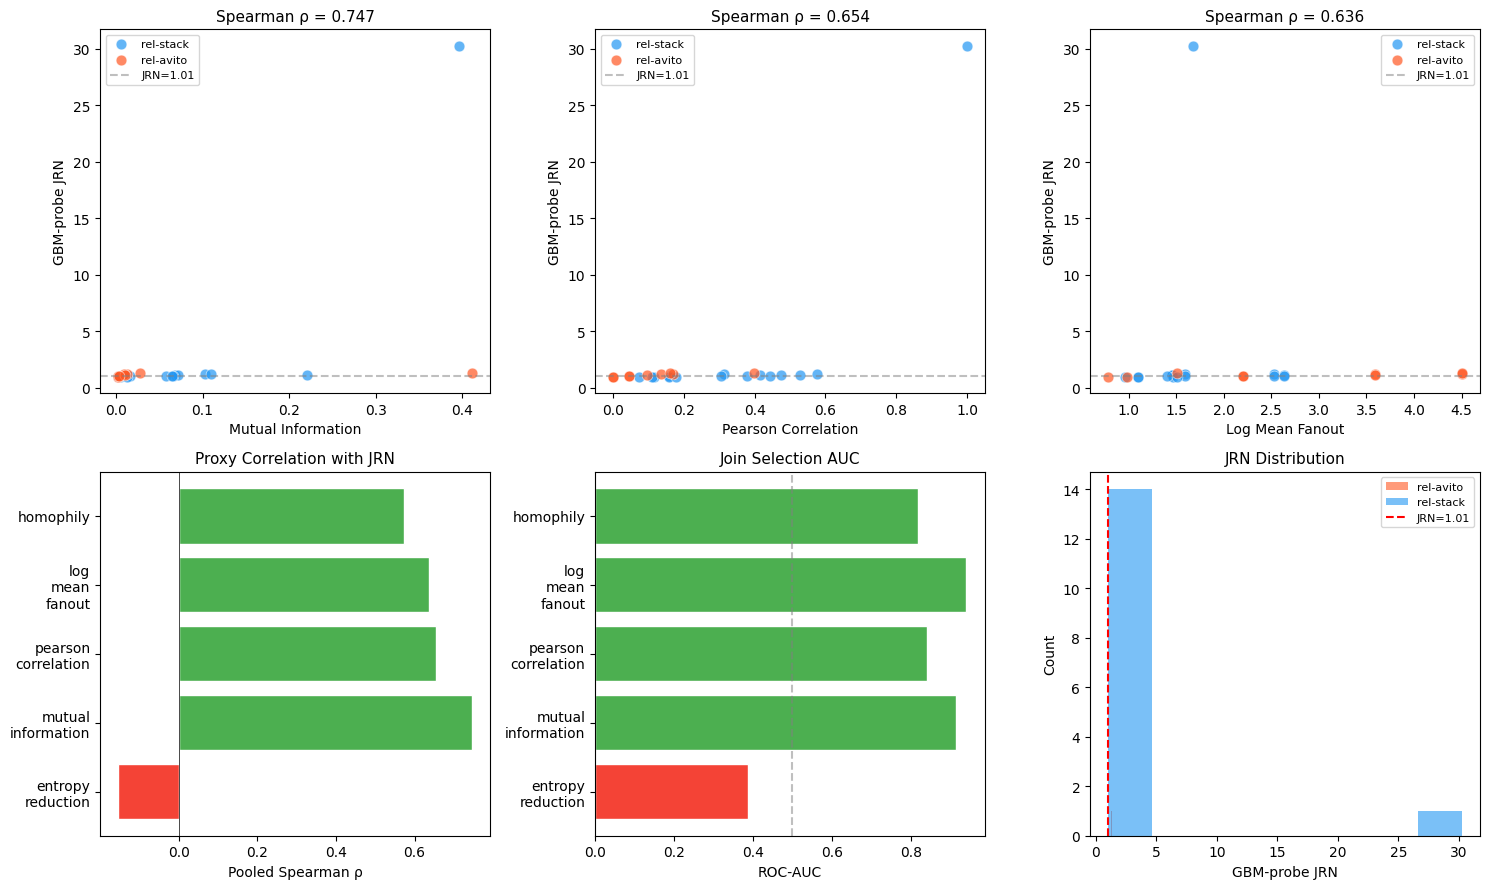

Saved visualization to jrn_proxy_analysis.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# ── Top row: Scatter plots of top 3 proxies vs JRN ──
top_proxies = sorted(PROXY_NAMES, key=lambda p: abs(pooled_rhos[p]), reverse=True)[:3]
colors = {"rel-stack": "#2196F3", "rel-avito": "#FF5722"}

for ax, proxy in zip(axes[0], top_proxies):
    for ds in df["dataset"].unique():
        subset = df[df["dataset"] == ds]
        ax.scatter(subset[proxy], subset["jrn_mean"], c=colors.get(ds, "gray"),
                   label=ds, alpha=0.7, s=60, edgecolors="white", linewidth=0.5)
    ax.set_xlabel(proxy.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("GBM-probe JRN", fontsize=10)
    rho = pooled_rhos[proxy]
    ax.set_title(f"Spearman ρ = {rho:.3f}", fontsize=11)
    ax.axhline(y=JRN_THRESHOLD, color="gray", linestyle="--", alpha=0.5, label=f"JRN={JRN_THRESHOLD}")
    ax.legend(fontsize=8)

# ── Bottom-left: Pooled Spearman rho bar chart ──
ax_rho = axes[1][0]
proxy_labels = [p.replace("_", "\n") for p in PROXY_NAMES]
rho_vals = [pooled_rhos[p] for p in PROXY_NAMES]
bar_colors = ["#4CAF50" if r > 0.5 else "#FFC107" if r > 0 else "#F44336" for r in rho_vals]
ax_rho.barh(proxy_labels, rho_vals, color=bar_colors, edgecolor="white")
ax_rho.set_xlabel("Pooled Spearman ρ", fontsize=10)
ax_rho.set_title("Proxy Correlation with JRN", fontsize=11)
ax_rho.axvline(x=0, color="black", linewidth=0.5)

# ── Bottom-middle: Join Selection AUC bar chart ──
ax_auc = axes[1][1]
auc_vals = [selection_auc.get(p, 0) for p in PROXY_NAMES]
bar_colors_auc = ["#4CAF50" if a > 0.8 else "#FFC107" if a > 0.5 else "#F44336" for a in auc_vals]
ax_auc.barh(proxy_labels, auc_vals, color=bar_colors_auc, edgecolor="white")
ax_auc.set_xlabel("ROC-AUC", fontsize=10)
ax_auc.set_title("Join Selection AUC", fontsize=11)
ax_auc.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)

# ── Bottom-right: JRN distribution by dataset ──
ax_dist = axes[1][2]
for ds in sorted(df["dataset"].unique()):
    subset = df[df["dataset"] == ds]
    ax_dist.hist(subset["jrn_mean"], bins=8, alpha=0.6, label=ds, color=colors.get(ds, "gray"))
ax_dist.axvline(x=JRN_THRESHOLD, color="red", linestyle="--", label=f"JRN={JRN_THRESHOLD}")
ax_dist.set_xlabel("GBM-probe JRN", fontsize=10)
ax_dist.set_ylabel("Count", fontsize=10)
ax_dist.set_title("JRN Distribution", fontsize=11)
ax_dist.legend(fontsize=8)

plt.tight_layout()
plt.savefig("jrn_proxy_analysis.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved visualization to jrn_proxy_analysis.png")